# ER1: No-Communication Control

Multi-agent coordination emerges from two sources: **what agents learn** and **what agents share**.
Before measuring the value of communication, we need to isolate the first factor — how well can agents learn to coordinate through observation alone?

This notebook trains agents on the Discovery K-N convergence task with **zero communication channels**.
The result is a performance floor: any communication protocol (ER2–E1) that fails to beat this floor adds complexity without benefit.

> **Research question:** Under partial observability and no message passing, how much of the rendezvous task can MARL policies solve through individual learning alone?

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent.parent.parent
RENDEZVOUS_ROOT = REPO_ROOT / "rendezvous_comm"
sys.path.insert(0, str(RENDEZVOUS_ROOT))

In [2]:
import torch
import matplotlib.pyplot as plt

from src.config import load_experiment
from src.storage import ExperimentStorage
from src.runner import run_sweep, evaluate_with_vmas, make_heuristic_policy_fn
from src.display import (
    display_config, display_sweep_summary,
    display_environment_info, scrollable_md, display_metric_cards, display_verdict,
    display_config_selector,
    display_baseline_comparison, display_results_dashboard,
    display_training_videos, display_artifact_tree,
)
from src.plotting import (
    plot_sweep_heatmap, plot_seed_variance, plot_training_dashboard,
    plot_baseline_grouped_bars, plot_results_comparison,
    plot_sweep_overview, save_figure,
)

print(f"Torch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

Torch: 2.10.0  |  CUDA: False


In [3]:
# ── Available configs with freshness status ──
display_config_selector("er1")

#,Config,Algo,N agents,LiDAR,Runs,Complete,Freshness
1,demo.yaml,"MAPPO, IPPO",4-8,0.35,8,6/8,VALID
2,single_mappo_n4_l035.yaml,MAPPO,4,0.35,1,1/1,CONFIG CHANGED
3,sweep_mappo-ippo_n2-6_l025-045.yaml,"MAPPO, IPPO",4-8,0.25-0.45,54,3/54,CONFIG CHANGED


## Configuration

Select a config from the dropdown above. Each YAML is self-contained — filename encodes what's inside:
- `single_*` → 1 run for quick validation (~15 min on CPU)
- `sweep_*` → full parameter sweep (hours/days)

Freshness badges: **VALID** = results match current config+code, **CONFIG/CODE CHANGED** = results are stale, **NEW** = no results yet.

The cell below loads the selected config and displays environment dimensions.

In [4]:
# ── Select config here ──
# Pick from the table above. Change the filename to switch configs.
#CONFIG_FILE_NAME = "single_mappo_n4_l035.yaml"
#CONFIG_FILE_NAME = "sweep_mappo-ippo_n2-6_l025-045.yaml"
CONFIG_FILE_NAME = "demo.yaml"

CONFIG = RENDEZVOUS_ROOT / "configs" / "er1" / CONFIG_FILE_NAME
FORCE_RETRAIN = False  # Set True to re-run even if results exist

spec = load_experiment(CONFIG)
spec.ensure_dirs()

display_environment_info(spec)

In [5]:
display_config(spec)

## Measurement Strategy

We evaluate along three axes relevant to the no-comm baseline:

| Category | Metric | Computation | Interpretation |
|----------|--------|-------------|----------------|
| **Task** | M1 Success Rate | `mean(targets_covered_total ≥ N_targets)` | Fraction of episodes where **all** targets were covered (not time-truncated) |
| | M2 Avg Return | `mean(Σ_t Σ_i r_i,t)` | Cumulative reward per episode, summed across agents and steps (covering − collisions − time) |
| | M3 Avg Steps | `mean(done_step)`, `max_steps` if incomplete | Steps until all targets covered; lower = faster |
| | M6 Coverage Progress | `mean(min(covered, N_targets) / N_targets)` | Partial credit: fraction of targets covered by episode end |
| **Safety** | M4 Collisions/Ep | `mean(Σ_t Σ_i 𝟙[collision_rew_i,t < 0])` | Count of agent-agent collision events per episode |
| **Coordination** | M8 Agent Utilization | `mean(std(c_i) / mean(c_i))` where `c_i` = agent *i*'s covering count | CV of per-agent covering contributions; 0 = perfectly balanced |
| | M9 Spatial Spread | `mean(1/T Σ_t mean_pairs ‖pos_i − pos_j‖)` | Mean pairwise agent distance averaged over time; higher = exploring |

**M5 (Tokens)** is always 0 here — it becomes meaningful in ER2+.
**M7 (Sample Efficiency)** = training frames to reach 80% of final eval reward (computed post-hoc from BenchMARL CSVs).

### Reference baselines
Before training, we measure two non-learned policies to calibrate expectations:

ID,Metric,Heuristic,Random
M1,Success Rate,10.0%,0.0%
M2,Avg Return,-8.00,-7.84
M3,Avg Steps,192.3,200.0
M4,Collisions/Episode,80.85,2.21
M6,Coverage Progress,61.9%,2.7%
M9,Spatial Spread,0.703,1.079

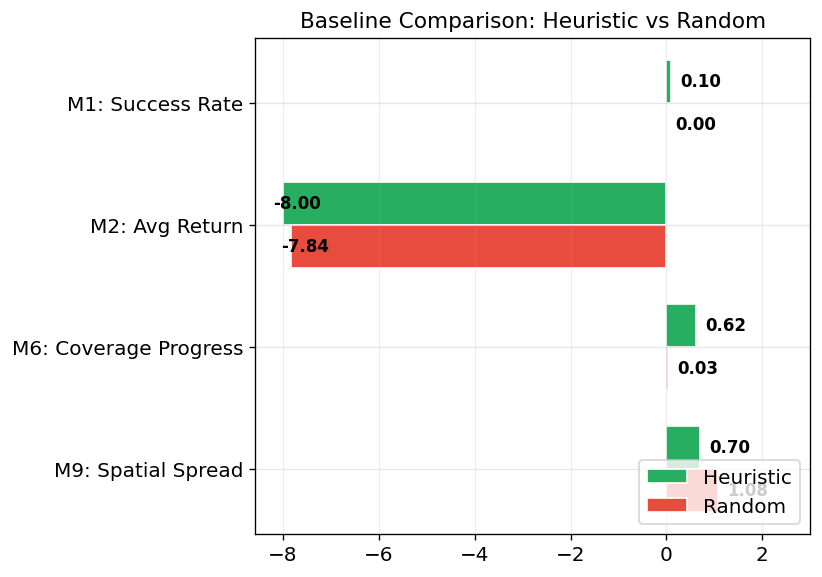

In [6]:
SANITY_OVERRIDES = {
    "n_agents": 4, "n_targets": 7, "agents_per_target": 2,
    "targets_respawn": False,
}

heuristic_fn = make_heuristic_policy_fn()
heuristic_metrics = evaluate_with_vmas(
    spec.task, task_overrides=SANITY_OVERRIDES,
    policy_fn=heuristic_fn, n_eval_episodes=200, n_envs=200,
)

random_metrics = evaluate_with_vmas(
    spec.task, task_overrides=SANITY_OVERRIDES,
    policy_fn=None, n_eval_episodes=200, n_envs=200,
)

# Grouped bar chart + comparison table side-by-side
fig = plot_baseline_grouped_bars(heuristic_metrics, random_metrics)
display_baseline_comparison(heuristic_metrics, random_metrics, fig=fig)

## Training

Each run: freeze config → train with BenchMARL (MAPPO/IPPO) → save policy → evaluate → save metrics + report.
Set `skip_complete=True` to resume interrupted sweeps without re-running finished runs.

In [7]:
results = run_sweep(spec, skip_complete=not FORCE_RETRAIN)

ER1 sweep:   0%|          | 0/8 [00:00<?, ]

  er1_ippo_n8_t7_k2_l035_s0:   0%|          | 0/100 [00:00<?]


2026-03-12 08:52:52.559 Python[15105:14518066] ApplePersistenceIgnoreState: Existing state will not be touched. New state will be written to /var/folders/qf/45hpwykd6s58js26xgtbw3tm0000gn/T/org.python.python.savedState

















KeyboardInterrupt: 

## Training Curves

BenchMARL logs scalar metrics at each iteration. The 3×2 dashboard shows six training signals:

| Panel | BenchMARL scalar | What it measures | What to look for |
|-------|-----------------|------------------|------------------|
| **Eval Reward** | `eval_reward_episode_reward_mean` | M2 during eval: `Σ_t Σ_i r_i,t` averaged over eval episodes | Upward trend; dashed line = heuristic baseline |
| **Targets Covered** | `collection_agents_info_targets_covered` | Per-step target covering events during collection | Should increase as agents learn the objective |
| **Covering Reward** | `collection_agents_info_covering_reward` | Reward component from covering: `covering_rew_coeff × 𝟙[K agents in range]` | Increasing = agents learn to converge on targets |
| **Collision Penalty** | `collection_agents_info_collision_rew` | Penalty signal: `agent_collision_penalty × 𝟙[dist < min_collision_dist]` | Should trend toward 0 (fewer collisions) |
| **Eval Episode Length** | `eval_reward_episode_len_mean` | Mean steps per eval episode (capped at `max_steps`) | Decreasing = agents complete the task faster |
| **Policy Entropy** | `train_agents_entropy` | Shannon entropy of the policy action distribution | Should decrease gradually; collapse to 0 = bad |

In [ ]:
storage = ExperimentStorage(spec.exp_id)

# Only show runs from the current sweep
all_metrics = {k: v for k, v in storage.load_all_metrics().items() if k in results}

if not all_metrics:
    print("No completed runs yet. Run the training cell first.")
elif len(all_metrics) == 1:
    # Single run — render directly, no dropdown needed
    run_id = list(all_metrics.keys())[0]
    rs = storage.get_run(run_id)
    scalars = rs.load_benchmarl_scalars()
    if scalars:
        from src.plotting import set_style
        m1_data = scalars.get("eval_M1_success_rate")
        m4_data = scalars.get("eval_M4_avg_collisions")
        if m1_data or m4_data:
            set_style()
            fig_m, (ax1, ax4) = plt.subplots(1, 2, figsize=(12, 3.5))
            if m1_data:
                s, v = zip(*m1_data)
                ax1.plot(s, v, color="#1f77b4", linewidth=1.8, marker="o", markersize=4)
                ax1.fill_between(s, v, alpha=0.1, color="#1f77b4")
                h = heuristic_metrics.get("M1_success_rate")
                if h is not None:
                    ax1.axhline(y=h, color="#27ae60", ls="--", lw=1.5, alpha=0.7, label=f"Heuristic ({h:.0%})")
                    ax1.legend(fontsize=9)
            ax1.set_ylim(0, 1.05); ax1.set_title("M1 — Success Rate"); ax1.set_xlabel("Iteration"); ax1.grid(True, alpha=0.3)
            if m4_data:
                s, v = zip(*m4_data)
                ax4.plot(s, v, color="#e74c3c", linewidth=1.8, marker="o", markersize=4)
                ax4.fill_between(s, v, alpha=0.1, color="#e74c3c")
                h = heuristic_metrics.get("M4_avg_collisions")
                if h is not None:
                    ax4.axhline(y=h, color="#27ae60", ls="--", lw=1.5, alpha=0.7, label=f"Heuristic ({h:.1f})")
                    ax4.legend(fontsize=9)
            ax4.set_title("M4 — Avg Collisions"); ax4.set_xlabel("Iteration"); ax4.grid(True, alpha=0.3)
            fig_m.suptitle(f"Eval Metrics — {run_id}", fontsize=13, fontweight="bold")
            fig_m.tight_layout()
            save_figure(fig_m, str(rs.output_dir / "m1_m4_training.png")); plt.show()
        fig = plot_training_dashboard(scalars, title=f"Training Progress — {run_id}", heuristic_reward=heuristic_metrics.get("M2_avg_return"))
        save_figure(fig, str(rs.output_dir / "training_dashboard.png")); plt.show()
    else:
        print(f"No BenchMARL scalars found for {run_id}.")
else:
    # Multiple runs — use dropdown
    from src.display import make_run_selector
    from src.plotting import set_style

    run_ids = sorted(all_metrics.keys(), reverse=True)

    def _render_dashboard(run_id):
        rs = storage.get_run(run_id)
        scalars = rs.load_benchmarl_scalars()
        if not scalars:
            print(f"No BenchMARL scalars found for {run_id}."); return
        m1_data = scalars.get("eval_M1_success_rate")
        m4_data = scalars.get("eval_M4_avg_collisions")
        if m1_data or m4_data:
            set_style()
            fig_m, (ax1, ax4) = plt.subplots(1, 2, figsize=(12, 3.5))
            if m1_data:
                s, v = zip(*m1_data)
                ax1.plot(s, v, color="#1f77b4", linewidth=1.8, marker="o", markersize=4)
                ax1.fill_between(s, v, alpha=0.1, color="#1f77b4")
                h = heuristic_metrics.get("M1_success_rate")
                if h is not None:
                    ax1.axhline(y=h, color="#27ae60", ls="--", lw=1.5, alpha=0.7, label=f"Heuristic ({h:.0%})")
                    ax1.legend(fontsize=9)
            ax1.set_ylim(0, 1.05); ax1.set_title("M1 — Success Rate"); ax1.set_xlabel("Iteration"); ax1.grid(True, alpha=0.3)
            if m4_data:
                s, v = zip(*m4_data)
                ax4.plot(s, v, color="#e74c3c", linewidth=1.8, marker="o", markersize=4)
                ax4.fill_between(s, v, alpha=0.1, color="#e74c3c")
                h = heuristic_metrics.get("M4_avg_collisions")
                if h is not None:
                    ax4.axhline(y=h, color="#27ae60", ls="--", lw=1.5, alpha=0.7, label=f"Heuristic ({h:.1f})")
                    ax4.legend(fontsize=9)
            ax4.set_title("M4 — Avg Collisions"); ax4.set_xlabel("Iteration"); ax4.grid(True, alpha=0.3)
            fig_m.suptitle(f"Eval Metrics — {run_id}", fontsize=13, fontweight="bold")
            fig_m.tight_layout()
            save_figure(fig_m, str(rs.output_dir / "m1_m4_training.png")); plt.show()
        fig = plot_training_dashboard(scalars, title=f"Training Progress — {run_id}", heuristic_reward=heuristic_metrics.get("M2_avg_return"))
        save_figure(fig, str(rs.output_dir / "training_dashboard.png")); plt.show()

    display(make_run_selector(run_ids, _render_dashboard))

In [ ]:
from IPython.display import clear_output
clear_output(wait=True)

# Videos are only available for the FIRST run in a sweep.
# Pyglet's display singleton goes stale after the first window close
# (known bug: pyglet#953), so rendering is auto-disabled for subsequent
# runs to avoid crashes. To get videos for a specific config, run it
# as a single_* config or place it first in the sweep.
if all_metrics:
    first_run_id = sorted(all_metrics.keys())[0]
    rs = storage.get_run(first_run_id)
    display_training_videos(rs)

## Results

In [ ]:
if not all_metrics:
    print("No completed runs yet.")
elif len(all_metrics) == 1:
    run_id = list(all_metrics.keys())[0]
    trained_metrics = all_metrics[run_id]
    run_storage = storage.get_run(run_id)
    comparison = {"Random": random_metrics, "Heuristic": heuristic_metrics, "Trained": trained_metrics}
    fig = plot_results_comparison(comparison)
    save_figure(fig, str(run_storage.output_dir / "results_comparison.png"))
    display_results_dashboard(trained_metrics, comparison_fig=fig, run_id=run_id)
else:
    from src.display import make_run_selector
    run_ids = sorted(all_metrics.keys(), reverse=True)

    def _render_results(run_id):
        trained_metrics = all_metrics[run_id]
        run_storage = storage.get_run(run_id)
        comparison = {"Random": random_metrics, "Heuristic": heuristic_metrics, "Trained": trained_metrics}
        fig = plot_results_comparison(comparison)
        save_figure(fig, str(run_storage.output_dir / "results_comparison.png"))
        display_results_dashboard(trained_metrics, comparison_fig=fig, run_id=run_id)

    display(make_run_selector(run_ids, _render_results))

## Sweep Analysis

With a `sweep_*` config, we can compare success across agent counts, LiDAR ranges, and algorithms.
If you used a `single_*` config, this section will be skipped (only 1 run).

In [ ]:
from IPython.display import clear_output
clear_output(wait=True)

if all_metrics and len(all_metrics) > 1:
    df = storage.to_dataframe()
    if not df.empty:
        # M1 Success rate heatmap across configs
        if "n_agents" in df.columns and len(df["n_agents"].unique()) > 1:
            fig = plot_sweep_heatmap(
                df, metric="M1_success_rate",
                row_param="n_agents", col_param="lidar_range",
                title="ER1: M1 Success Rate (N agents × LiDAR range)",
            )
            save_figure(fig, str(spec.results_dir / "sweep_success_heatmap.png"))
            plt.show()

            # M4 Collisions heatmap
            fig = plot_sweep_heatmap(
                df, metric="M4_avg_collisions",
                row_param="n_agents", col_param="lidar_range",
                title="ER1: M4 Collisions (N agents × LiDAR range)",
            )
            save_figure(fig, str(spec.results_dir / "sweep_collisions_heatmap.png"))
            plt.show()

        # Algorithm comparison
        if "algorithm" in df.columns and len(df["algorithm"].unique()) > 1:
            fig = plot_seed_variance(
                df, metric="M1_success_rate", group_by="algorithm",
                title="ER1: MAPPO vs IPPO — M1 Success Rate (across seeds)",
            )
            save_figure(fig, str(spec.results_dir / "sweep_algo_comparison.png"))
            plt.show()
else:
    print("Sweep analysis requires multiple runs. Use a sweep config and re-run.")

## Interpretation

The scatter plots below show metric relationships across all runs. Key questions:

| Plot | Axes | What to look for |
|------|------|-----------------|
| **Safety tradeoff** | M1 vs M4 | Do high-success runs also have high collisions? If so, agents brute-force coverage by crowding. |
| **Speed** | M1 vs M3 | Are successful runs also fast? M3 ≈ max_steps means agents barely finish in time. |
| **Balance** | M6 vs M8 | High coverage with low utilization CV = agents share work. High CV = some agents idle. |
| **Exploration** | M1 vs M9 | Does spatial spread help or hurt? Communication should improve this tradeoff. |

In [ ]:
from IPython.display import clear_output
clear_output(wait=True)

if all_metrics:
    df = storage.to_dataframe()

    # ── Multi-metric overview scatter (all runs) ──
    if not df.empty and len(all_metrics) > 1:
        fig = plot_sweep_overview(df, title="ER1: Metric Relationships (all runs)")
        save_figure(fig, str(spec.results_dir / "sweep_metric_overview.png"))
        plt.show()

    # ── Verdict ──
    if not df.empty:
        if "n_agents" in df.columns and 4 in df["n_agents"].values:
            sub = df[df["n_agents"] == 4]
        else:
            sub = df
        display_verdict(
            sub["M1_success_rate"].mean(),
            sub["M2_avg_return"].mean(),
        )

    # ── Cross-run observations ──
    if len(all_metrics) > 1 and not df.empty:
        notes = []
        mean_sr = df["M1_success_rate"].mean()
        mean_coll = df["M4_avg_collisions"].mean()
        mean_cov = df["M6_coverage_progress"].mean()
        mean_util = df["M8_agent_utilization"].mean()
        if mean_sr > 0.8 and mean_coll > 10:
            notes.append(
                "High average M1 but also high M4 — agents crowd "
                "targets to achieve coverage, causing collisions."
            )
        if mean_sr < 0.3 and mean_cov > 0.5:
            notes.append(
                "Low M1 but decent M6 — agents cover most targets "
                "but fail on the last few. Communication could help."
            )
        if mean_util > 0.8:
            notes.append(
                "High M8 across runs — unbalanced workload. "
                "Some agents idle while others do the covering."
            )
        if mean_sr > 0.5 and mean_coll < 5:
            notes.append(
                "Good M1 with low M4 — agents solve the task "
                "without excessive collisions."
            )
        if notes:
            print("Cross-run observations:")
            print("\n".join(f"  → {n}" for n in notes))

## Report & Run Details

The sweep report below aggregates all runs (config, metrics, best/worst).
Use the dropdown to inspect individual run reports with full training stats and artifacts.

In [ ]:
if all_metrics:
    from src.report import generate_sweep_report

    sweep_report = generate_sweep_report(spec, all_metrics)
    scrollable_md(sweep_report, height=500, title="Sweep Report (all runs)")

    if len(all_metrics) == 1:
        run_id = list(all_metrics.keys())[0]
        rs = storage.get_run(run_id)
        report_path = rs.run_dir / "report.md"
        if report_path.exists():
            scrollable_md(report_path.read_text(), height=400, title=f"Run Report — {run_id}")
    else:
        from src.display import make_run_selector
        run_ids = sorted(all_metrics.keys(), reverse=True)

        def _render_report(run_id):
            rs = storage.get_run(run_id)
            report_path = rs.run_dir / "report.md"
            if report_path.exists():
                scrollable_md(report_path.read_text(), height=400, title=f"Run Report — {run_id}")
            else:
                print(f"No report.md found for {run_id}")

        display(make_run_selector(run_ids, _render_report))

## Output Artifacts

Each run is self-contained in its timestamped folder. Browse the file tree and policy info below.

In [ ]:
if not all_metrics:
    print("No completed runs.")
elif len(all_metrics) == 1:
    run_id = list(all_metrics.keys())[0]
    rs = storage.get_run(run_id)
    display_artifact_tree(rs)
    if rs.has_policy():
        sd = rs.load_policy_state_dict()
        if sd:
            total = sum(p.numel() for p in sd.values() if p is not None)
            print(f"\nPolicy: {len(sd)} tensors, {total:,} parameters")
            print(f"File:   {rs.output_dir / 'policy.pt'}")
else:
    from src.display import make_run_selector
    run_ids = sorted(all_metrics.keys(), reverse=True)

    def _render_artifacts(run_id):
        rs = storage.get_run(run_id)
        display_artifact_tree(rs)
        if rs.has_policy():
            sd = rs.load_policy_state_dict()
            if sd:
                total = sum(p.numel() for p in sd.values() if p is not None)
                print(f"\nPolicy: {len(sd)} tensors, {total:,} parameters")
                print(f"File:   {rs.output_dir / 'policy.pt'}")

    display(make_run_selector(run_ids, _render_artifacts))